# Notebook 2 — Promotion Causality
### Which part of the lift is actually *caused* by the promotion, and how it varies by factor

Notebook 1 measured sales against a seasonal baseline and found **+115%** on promoted weeks.

That is still not a causal number. A baseline knows how the market moves in week 40 — it does not know that the retailer *chose* to promote soft drinks in week 40 precisely because demand was already climbing. Any demand the buyer anticipated is credited to the promotion.

**The fix is a real control group.** In a week where an item is promoted in *some* stores and not others, the non-promoting stores are the counterfactual: same product, same week, same weather, same season — no promotion.

$$\text{causal lift}=\frac{\text{index}_{\text{promoted stores}}}{\text{index}_{\text{control stores}}}-1,\qquad \text{index}=\frac{\text{actual}}{\text{baseline}}$$

| Section | Question |
|---|---|
| 1 | Is promotion targeting random? (selection evidence) |
| 2 | Headline causal lift vs the raw number |
| 3 | **Factor grid A — promotion mechanics**: display position, mailer position, mechanism, depth |
| 4 | **Factor grid B — product**: brand, category, price tier |
| 5 | **Factor grid C — context**: season, promo fatigue, store intensity |
| 6 | **Factor grid D — customers**: which households respond |
| 7 | Before / during / after |
| 8 | Factor ranking |
| 9 | **Placebo test** — does the method invent effects that are not there? |
| 10 | **Synthetic-truth test** — does it recover an effect of known size? |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt

BASE = "."
ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","axes.edgecolor":"#c3c2b7",
    "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.6,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"font.size":10,"axes.titlesize":11,
    "axes.titleweight":"bold","xtick.color":MUTED,"ytick.color":MUTED,"legend.frameon":False})
pd.set_option("display.width", 220); pd.set_option("display.max_rows", 90)

CATEGORIES = ["SOFT DRINKS","CHEESE","BAG SNACKS","FROZEN PIZZA","CRACKERS/MISC BKD FD",
              "COLD CEREAL","FRZN MEAT/MEAT DINNERS","YOGURT","ICE CREAM/MILK/SHERBTS","COOKIES/CONES"]
DISPLAY_NAME = {"0":"not on display","1":"store front","2":"store rear","3":"front end cap",
                "4":"mid-aisle end cap","5":"rear end cap","6":"side-aisle end cap",
                "7":"front shelf","8":"mid-shelf","9":"rear shelf","A":"promo shelf"}
MAILER_NAME  = {"0":"not in mailer","A":"interior page feature","C":"interior page line item",
                "D":"front page feature","F":"back page feature","H":"wrap front feature",
                "J":"wrap interior coupon","L":"wrap back feature","P":"interior page coupon",
                "X":"free on interior page","Z":"free on front/back/wrap"}
print("scope:", len(CATEGORIES), "categories")

scope: 10 categories


## 0. Rebuild the panel

This notebook stands alone, so it rebuilds the same weekly panel and the same baseline as notebook 1.

In [2]:
product = pd.read_csv(f"{BASE}/product.csv")
pm = product[["PRODUCT_ID","COMMODITY_DESC","SUB_COMMODITY_DESC","DEPARTMENT",
              "BRAND","MANUFACTURER"]].drop_duplicates("PRODUCT_ID")
sel_pids = set(pm.loc[pm.COMMODITY_DESC.isin(CATEGORIES), "PRODUCT_ID"])
tx = pd.read_csv(f"{BASE}/transaction_data.csv",
    dtype={"household_key":"int32","BASKET_ID":"int64","DAY":"int16","PRODUCT_ID":"int32",
           "QUANTITY":"int32","SALES_VALUE":"float32","STORE_ID":"int32","RETAIL_DISC":"float32",
           "TRANS_TIME":"int32","WEEK_NO":"int16","COUPON_DISC":"float32","COUPON_MATCH_DISC":"float32"})
parts = []
for ch in pd.read_csv(f"{BASE}/causal_data.csv", chunksize=6_000_000,
                      dtype={"PRODUCT_ID":"int32","STORE_ID":"int32","WEEK_NO":"int16",
                             "display":"str","mailer":"str"}):
    parts.append(ch[ch.PRODUCT_ID.isin(sel_pids)])
cz = pd.concat(parts, ignore_index=True); del parts
DRANK = {"0":0,"7":1,"8":1,"9":1,"A":2,"1":3,"2":3,"3":3,"4":3,"5":3,"6":3}
MRANK = {"0":0,"C":1,"A":2,"P":2,"J":2,"D":3,"F":3,"H":3,"L":3,"X":3,"Z":3}
cz["d_rank"] = cz.display.map(DRANK).fillna(0).astype(np.int8)
cz["m_rank"] = cz.mailer.map(MRANK).fillna(0).astype(np.int8)
cz = (cz.sort_values(["d_rank","m_rank"])
        .groupby(["PRODUCT_ID","STORE_ID","WEEK_NO"], as_index=False)
        .agg(display=("display","last"), mailer=("mailer","last"),
             d_rank=("d_rank","max"), m_rank=("m_rank","max")))
STORES = set(cz.STORE_ID.unique()); W0, W1 = int(cz.WEEK_NO.min()), int(cz.WEEK_NO.max())

t = tx[tx.PRODUCT_ID.isin(sel_pids) & tx.STORE_ID.isin(STORES) & tx.WEEK_NO.between(W0, W1)].copy()
t = t[(t.QUANTITY > 0) & (t.QUANTITY <= 50) & (t.SALES_VALUE > 0)]
t["retailer_disc"] = t.RETAIL_DISC.abs() + t.COUPON_MATCH_DISC.abs()
fact = t.groupby(["PRODUCT_ID","STORE_ID","WEEK_NO"], as_index=False).agg(
    units=("QUANTITY","sum"), revenue=("SALES_VALUE","sum"), retailer_disc=("retailer_disc","sum"))
hist = fact.groupby(["PRODUCT_ID","STORE_ID"]).WEEK_NO.nunique(); keep = hist[hist >= 20].index
df = (pd.DataFrame(list(keep), columns=["PRODUCT_ID","STORE_ID"])
        .merge(pd.DataFrame({"WEEK_NO": np.arange(W0, W1+1, dtype="int16")}), how="cross")
        .merge(fact, on=["PRODUCT_ID","STORE_ID","WEEK_NO"], how="left"))
for c in ["units","revenue","retailer_disc"]: df[c] = df[c].fillna(0.0)
df = df.merge(cz, on=["PRODUCT_ID","STORE_ID","WEEK_NO"], how="left")
df["display"] = df.display.fillna("0"); df["mailer"] = df.mailer.fillna("0")
df[["d_rank","m_rank"]] = df[["d_rank","m_rank"]].fillna(0).astype(np.int8)
df["on_display"] = (df.d_rank > 0).astype(np.int8)
df["on_mailer"]  = (df.m_rank > 0).astype(np.int8)
df["promo"] = ((df.on_display + df.on_mailer) > 0).astype(np.int8)
df["mech"] = np.where(df.on_display & df.on_mailer, "display + mailer",
             np.where(df.on_display == 1, "display only",
             np.where(df.on_mailer == 1, "mailer only", "none")))
df = df.merge(pm, on="PRODUCT_ID", how="left")
df["key"] = df.PRODUCT_ID.astype(str) + "_" + df.STORE_ID.astype(str)

nz = df[df.promo == 0]
season = (nz.groupby("WEEK_NO").units.mean()/nz.units.mean()).rename("season_idx")
level  = nz.groupby("key").units.mean().rename("base_level")
df = df.merge(season, on="WEEK_NO", how="left").merge(level, on="key", how="left")
df["base_level"] = df.base_level.fillna(0); df["baseline"] = df.base_level*df.season_idx

# price for every cell (imputed where nothing sold), so depth breakdowns cover failures too
df["price_obs"] = np.where(df.units > 0, df.revenue/df.units.replace(0, np.nan), np.nan)
pw = df.groupby(["PRODUCT_ID","WEEK_NO"]).price_obs.median().rename("_pw")
pp = df.groupby("PRODUCT_ID").price_obs.median().rename("_pp")
df = df.merge(pw, on=["PRODUCT_ID","WEEK_NO"], how="left").merge(pp, on="PRODUCT_ID", how="left")
df["price_est"] = df.price_obs.fillna(df["_pw"]).fillna(df["_pp"])
ref = df[df.promo == 0].groupby("key").price_est.median().rename("ref_price")
df = df.merge(ref, on="key", how="left")
df["cut_est"] = (1 - df.price_est/df.ref_price).clip(-1, 0.95)
df = df.drop(columns=["_pw","_pp"])

RAW_LIFT = 100*(df[df.promo==1].units.sum()/df[df.promo==1].baseline.sum() - 1)
print(f"panel {len(df):,} rows | {df.key.nunique():,} product-stores x {W1-W0+1} weeks")
print(f"RAW LIFT carried over from notebook 1: {RAW_LIFT:+.1f}%  <- the number now on trial")

panel 181,536 rows | 1,952 product-stores x 93 weeks
RAW LIFT carried over from notebook 1: +114.9%  <- the number now on trial


## 1. Is promotion targeting random?

If the buyer picked items and weeks at random, notebook 1's number would already be causal. Three pieces of evidence that it is not.

EVIDENCE OF NON-RANDOM TARGETING
  1. promo intensity swings across weeks: 12% to 52%,
     and it moves WITH market demand (corr = +0.18).
     Promotions are concentrated exactly where demand was going anyway.


  2. it is not simply 'big sellers get promoted': average weekly units are 0.60 for promoted vs 0.61 for non-promoted cells -- nearly identical.
     The selection is in the TIMING, not in the item. Section 7 shows sales already
     running above baseline in the weeks BEFORE a promotion starts.
  3. stores differ enormously in how much they promote: 0% to 66% of cells.

  => a before/after comparison credits the promotion with demand it did not create.


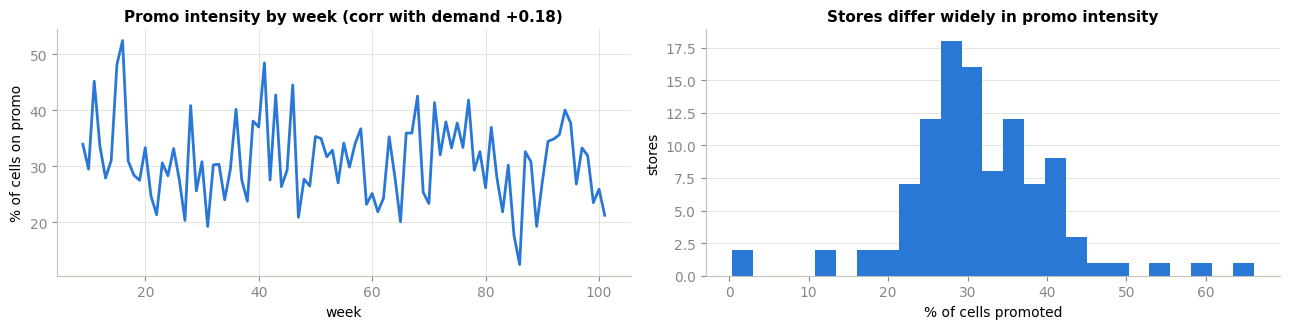

In [3]:
wk = df.groupby("WEEK_NO").agg(promo_share=("promo","mean"), units=("units","sum"))
print("EVIDENCE OF NON-RANDOM TARGETING")
print(f"  1. promo intensity swings across weeks: {wk.promo_share.min():.0%} to {wk.promo_share.max():.0%},")
print(f"     and it moves WITH market demand (corr = {wk.promo_share.corr(wk.units):+.2f}).")
print("     Promotions are concentrated exactly where demand was going anyway.")
avg = df.groupby("key").units.mean().rename("avg_units")
df = df.merge(avg, on="key", how="left")
print(f"  2. it is not simply 'big sellers get promoted': average weekly units are "
      f"{df[df.promo==1].avg_units.mean():.2f} for promoted vs {df[df.promo==0].avg_units.mean():.2f}"
      f" for non-promoted cells -- nearly identical.")
print("     The selection is in the TIMING, not in the item. Section 7 shows sales already")
print("     running above baseline in the weeks BEFORE a promotion starts.")
st = df.groupby("STORE_ID").promo.mean()
print(f"  3. stores differ enormously in how much they promote: {st.min():.0%} to {st.max():.0%} of cells.")
print("\n  => a before/after comparison credits the promotion with demand it did not create.")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
axes[0].plot(wk.index, 100*wk.promo_share, color=ACCENT, lw=2)
axes[0].set_xlabel("week"); axes[0].set_ylabel("% of cells on promo")
axes[0].set_title(f"Promo intensity by week (corr with demand {wk.promo_share.corr(wk.units):+.2f})")
axes[1].hist(100*st.values, bins=25, color=ACCENT)
axes[1].set_xlabel("% of cells promoted"); axes[1].set_ylabel("stores")
axes[1].set_title("Stores differ widely in promo intensity"); axes[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 2. Headline causal lift

The comparison set is every **product-week that was promoted in some stores and not others**. Inside that set, treated and control stores face identical demand conditions.

The control index is the diagnostic that matters: if the baseline predicts the untreated stores accurately in exactly these weeks, then the excess seen in treated stores is the promotion's own effect.

DIFFERENCE-IN-DIFFERENCES
  comparison set : 65,737 rows in mixed product-weeks
  treated cells  : 17,798   index vs baseline = 1.869
  control cells  : 47,939   index vs baseline = 1.017

  the control index of 1.017 is the validation: in these very weeks the baseline
  predicts non-promoting stores almost exactly, so the counterfactual holds up

  RAW    lift : +114.9%
  CAUSAL lift : +83.8%
  => 27% of the raw number was demand that was coming anyway


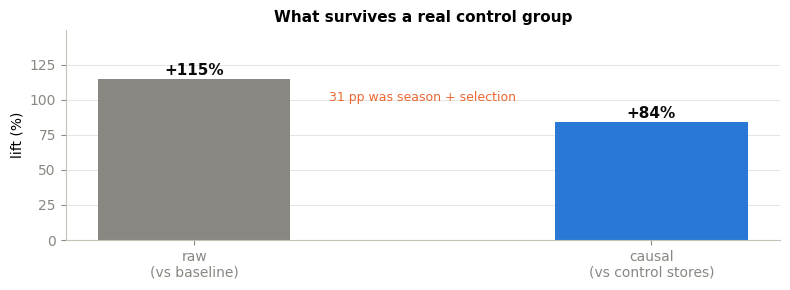

In [4]:
mix = df.groupby(["PRODUCT_ID","WEEK_NO"]).promo.transform("mean")
mixed = df[(mix > 0) & (mix < 1)].copy()

def did(frame, min_treated=80):
    # frame must contain both promoted and control rows; returns (causal lift %, control index, n)
    a, b = frame[frame.promo == 1], frame[frame.promo == 0]
    if len(a) < min_treated or a.baseline.sum() <= 0 or b.baseline.sum() <= 0:
        return np.nan, np.nan, len(a)
    it, ic = a.units.sum()/a.baseline.sum(), b.units.sum()/b.baseline.sum()
    return 100*(it/ic - 1), ic, len(a)

CAUSAL, ctrl_idx, n_tr = did(mixed)
print("DIFFERENCE-IN-DIFFERENCES")
print(f"  comparison set : {len(mixed):,} rows in mixed product-weeks")
print(f"  treated cells  : {n_tr:,}   index vs baseline = "
      f"{mixed[mixed.promo==1].units.sum()/mixed[mixed.promo==1].baseline.sum():.3f}")
print(f"  control cells  : {len(mixed)-n_tr:,}   index vs baseline = {ctrl_idx:.3f}")
print(f"\n  the control index of {ctrl_idx:.3f} is the validation: in these very weeks the baseline")
print("  predicts non-promoting stores almost exactly, so the counterfactual holds up")
print(f"\n  RAW    lift : {RAW_LIFT:+.1f}%")
print(f"  CAUSAL lift : {CAUSAL:+.1f}%")
print(f"  => {100*(1-CAUSAL/RAW_LIFT):.0f}% of the raw number was demand that was coming anyway")

fig, ax = plt.subplots(figsize=(8, 3.0))
bars = ax.bar(["raw\n(vs baseline)","causal\n(vs control stores)"], [RAW_LIFT, CAUSAL],
              color=[MUTED, ACCENT], width=0.42)
for b, v in zip(bars, [RAW_LIFT, CAUSAL]):
    ax.text(b.get_x()+b.get_width()/2, v+3, f"{v:+.0f}%", ha="center", fontsize=11,
            fontweight="bold", color=INK)
ax.text(0.5, (RAW_LIFT+CAUSAL)/2, f"{RAW_LIFT-CAUSAL:.0f} pp was season + selection",
        ha="center", fontsize=9, color=ACCENT2)
ax.set_ylabel("lift (%)"); ax.set_ylim(0, RAW_LIFT*1.3); ax.grid(axis="x", visible=False)
ax.set_title("What survives a real control group")
plt.tight_layout(); plt.show()

## 3. Factor grid A — promotion mechanics

Now the same DiD applied inside each level of each factor. This is where planning decisions actually get made.

For the **position** factors the other mechanism is switched off (display positions measured on weeks with no mailer, and vice versa) so the two do not contaminate each other.

In [5]:
def factor_did(frame, by, min_treated=80, name_map=None, isolate=None):
    # isolate: restrict to weeks where the OTHER mechanism is off, so positions are read cleanly
    f = frame if isolate is None else frame[isolate]
    ctrl = f[f.promo == 0]
    rows = []
    for lvl, g in f[f.promo == 1].groupby(by, observed=True):
        lift, ic, n = did(pd.concat([g, ctrl]), min_treated)
        if np.isnan(lift): continue
        rows.append({by: lvl, "name": (name_map or {}).get(lvl, lvl),
                     "treated_weeks": n, "causal_lift_%": round(lift, 1),
                     "control_idx": round(ic, 2),
                     "avg_depth_%": round(100*g.cut_est.mean(), 1),
                     "pct_with_price_cut": round(100*(g.cut_est > 0.02).mean(), 1)})
    return pd.DataFrame(rows).sort_values("causal_lift_%", ascending=False)

print("="*82); print("A1 -- MECHANISM"); print("="*82)
a1 = factor_did(mixed, "mech", min_treated=200)
print(a1.drop(columns="name").to_string(index=False))

print("\n" + "="*82); print("A2 -- DISPLAY POSITION  (weeks with no mailer)"); print("="*82)
a2 = factor_did(mixed, "display", 60, DISPLAY_NAME, isolate=(mixed.on_mailer == 0))
print(a2.to_string(index=False))

print("\n" + "="*82); print("A3 -- MAILER POSITION  (weeks with no display)"); print("="*82)
a3 = factor_did(mixed, "mailer", 40, MAILER_NAME, isolate=(mixed.on_display == 0))
print(a3.to_string(index=False))

print("\n" + "="*82); print("A4 -- DISCOUNT DEPTH"); print("="*82)
mixed["depth"] = pd.cut(mixed.cut_est, [-9,0.02,0.10,0.20,0.30,0.45,9],
                        labels=["~0% (ad only)","2-10%","10-20%","20-30%","30-45%","45%+"])
a4 = factor_did(mixed, "depth", 100)
print(a4.drop(columns="name").to_string(index=False))
print("\n  depth is the strongest single lever on volume -- and notebook 1 showed it is also")
print("  the strongest lever on cost, in the opposite direction")

A1 -- MECHANISM
            mech  treated_weeks  causal_lift_%  control_idx  avg_depth_%  pct_with_price_cut
display + mailer           1759          307.7         1.02         26.5                92.6
     mailer only           1304          149.5         1.02         13.8                66.9
    display only          14735           50.5         1.02          2.4                27.4

A2 -- DISPLAY POSITION  (weeks with no mailer)


display               name  treated_weeks  causal_lift_%  control_idx  avg_depth_%  pct_with_price_cut
      1        store front            462           90.7         1.02          2.5                31.2
      9         rear shelf           4307           58.9         1.02          0.4                24.3
      6 side-aisle end cap           1267           56.3         1.02          3.3                28.8
      7        front shelf           3389           51.7         1.02          3.5                32.3
      5       rear end cap           1343           51.3         1.02          2.6                20.9
      2         store rear           1570           46.2         1.02          2.1                27.6
      3      front end cap           1261           43.5         1.02          6.2                33.1
      4  mid-aisle end cap            485           23.7         1.02          2.3                32.6
      A        promo shelf            651           19.1         1.02    

        depth  treated_weeks  causal_lift_%  control_idx  avg_depth_%  pct_with_price_cut
         45%+            277          643.1         1.02         47.6               100.0
       30-45%           1338          325.2         1.02         33.9               100.0
       20-30%           1992          179.2         1.02         24.9               100.0
       10-20%           1638           70.3         1.02         13.3               100.0
        2-10%           1293           55.2         1.02          6.5               100.0
~0% (ad only)          11260           35.5         1.02         -3.4                 0.0

  depth is the strongest single lever on volume -- and notebook 1 showed it is also
  the strongest lever on cost, in the opposite direction


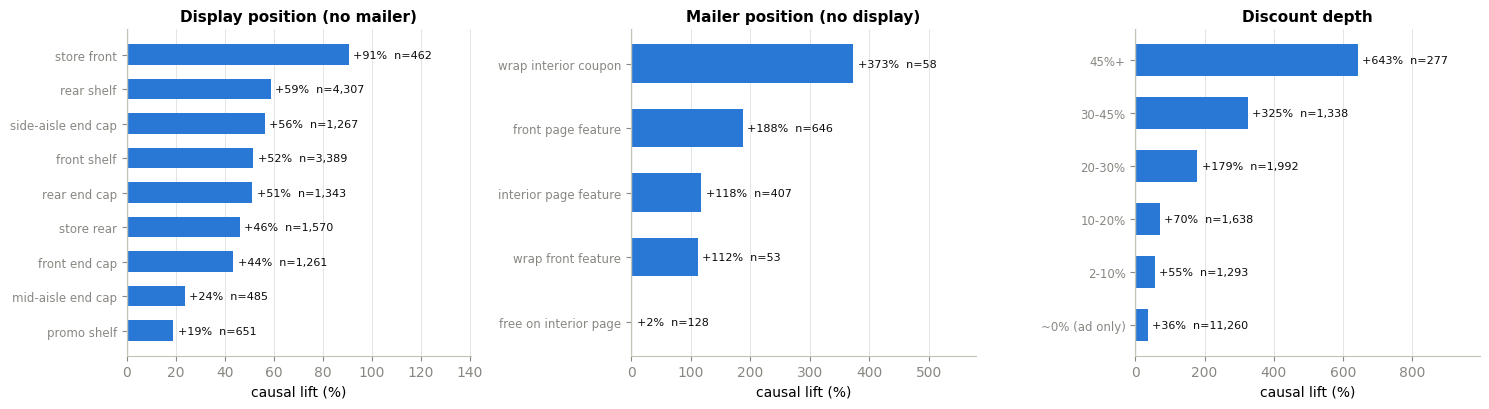

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

def lift_bar(ax, frame, labcol, title):
    o = frame.sort_values("causal_lift_%")
    ys = np.arange(len(o))
    ax.barh(ys, o["causal_lift_%"], color=ACCENT, height=0.6)
    ax.axvline(0, color="#c3c2b7", lw=1)
    span = max(abs(o["causal_lift_%"]).max(), 1)
    for i, (v, n) in enumerate(zip(o["causal_lift_%"], o.treated_weeks)):
        ax.text(v + (0.02*span if v >= 0 else -0.02*span), i, f"{v:+.0f}%  n={n:,}",
                va="center", ha="left" if v >= 0 else "right", fontsize=8, color=INK)
    ax.set_yticks(ys); ax.set_yticklabels([str(x)[:24] for x in o[labcol]], fontsize=8.5)
    ax.set_xlabel("causal lift (%)"); ax.set_title(title); ax.grid(axis="y", visible=False)
    ax.set_xlim(min(0, o["causal_lift_%"].min())*1.5, o["causal_lift_%"].max()*1.55)

lift_bar(axes[0], a2, "name", "Display position (no mailer)")
lift_bar(axes[1], a3, "name", "Mailer position (no display)")
lift_bar(axes[2], a4, "depth", "Discount depth")
plt.tight_layout(); plt.show()

## 4. Factor grid B — product attributes

B1 -- BRAND TIER
   BRAND  treated_weeks  causal_lift_%  control_idx  avg_depth_%  pct_with_price_cut
National          11228           99.8         1.02          6.8                39.6
 Private           6570           61.5         1.02          3.5                31.9

B2 -- CATEGORY


        COMMODITY_DESC  treated_weeks  causal_lift_%  control_idx  avg_depth_%  pct_with_price_cut
            BAG SNACKS           3808          115.7         1.02          5.9                31.7
           SOFT DRINKS           5558          103.5         1.02          7.4                47.9
                CHEESE           5136           83.9         1.02          6.6                40.2
  CRACKERS/MISC BKD FD           1731           43.6         1.02          0.9                23.9
FRZN MEAT/MEAT DINNERS            439           28.1         1.02          0.9                 8.0
         COOKIES/CONES            320           12.6         1.02          0.3                11.9
          FROZEN PIZZA            617            0.2         1.02         -0.6                13.1
                YOGURT            143           -6.9         1.02          0.8                16.8

B3 -- PRICE TIER (item's normal shelf price)
  price_tier  treated_weeks  causal_lift_%  control_idx  avg_de

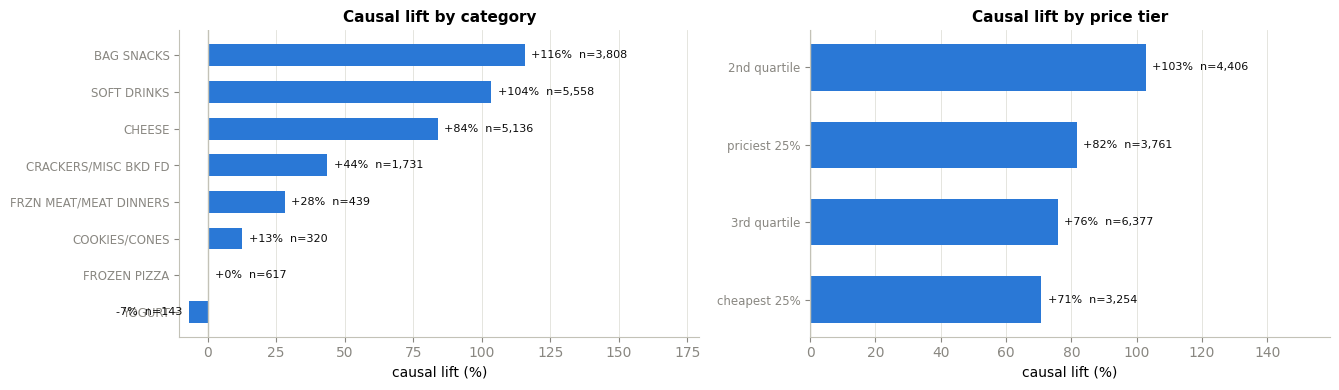

In [7]:
print("="*82); print("B1 -- BRAND TIER"); print("="*82)
b1 = factor_did(mixed, "BRAND", 200)
print(b1.drop(columns="name").to_string(index=False))

print("\n" + "="*82); print("B2 -- CATEGORY"); print("="*82)
b2 = factor_did(mixed, "COMMODITY_DESC", 100)
print(b2.drop(columns="name").to_string(index=False))

print("\n" + "="*82); print("B3 -- PRICE TIER (item's normal shelf price)"); print("="*82)
mixed["price_tier"] = pd.qcut(mixed.ref_price, 4,
                              labels=["cheapest 25%","2nd quartile","3rd quartile","priciest 25%"])
b3 = factor_did(mixed, "price_tier", 150)
print(b3.drop(columns="name").to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.0))
lift_bar(axes[0], b2, "COMMODITY_DESC", "Causal lift by category")
lift_bar(axes[1], b3, "price_tier", "Causal lift by price tier")
plt.tight_layout(); plt.show()

## 5. Factor grid C — context

Three context factors the planner controls: **when** in the year, **how long** the promotion has been running, and **how saturated** the store already is.

C1 -- SEASON (quarter within the year)
 quarter  treated_weeks  causal_lift_%  control_idx  avg_depth_%  pct_with_price_cut
       1           3143           33.1         1.02          1.8                30.2
       2           4182           64.5         1.02          3.1                30.2
       3           4925           83.0         1.02          5.0                34.6
       4           5548          123.6         1.02         10.1                47.3

C2 -- PROMO FATIGUE (which week of the promotion spell)


spell_wk  treated_weeks  causal_lift_%  control_idx  avg_depth_%  pct_with_price_cut
  week 1           4470          127.2         1.02         11.4                51.5
  week 2           2833           62.5         1.02          5.9                39.1
  week 3           1994           73.9         1.02          5.3                34.6
 week 4+           8501           68.5         1.02          2.5                28.7

  the first week of a promotion does most of the work; by week 2 the effect is roughly halved

C3 -- STORE PROMO INTENSITY
       store_bin  treated_weeks  causal_lift_%  control_idx  avg_depth_%  pct_with_price_cut
 low-promo store           4870           91.4         1.02          6.5                38.7
          medium           5571           82.0         1.02          6.5                38.1
high-promo store           7357           79.9         1.02          4.3                34.4

  stores that promote less get more out of each promotion -- diminishing retur

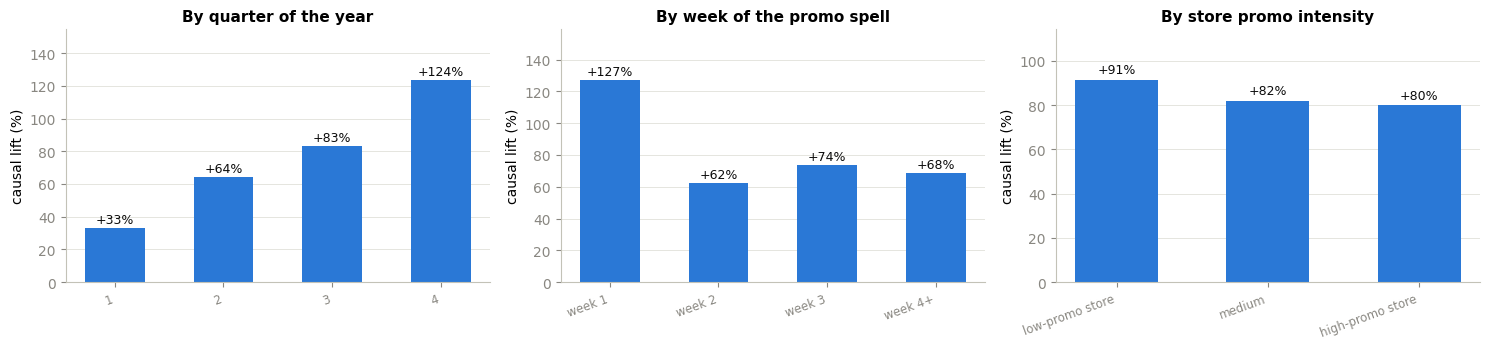

In [8]:
print("="*82); print("C1 -- SEASON (quarter within the year)"); print("="*82)
mixed["quarter"] = ((mixed.WEEK_NO - 1) // 13) % 4 + 1
c1 = factor_did(mixed, "quarter", 150).sort_values("quarter")
print(c1.drop(columns="name").to_string(index=False))

print("\n" + "="*82); print("C2 -- PROMO FATIGUE (which week of the promotion spell)"); print("="*82)
d = df.sort_values(["key","WEEK_NO"]).copy()
d["prev"]  = d.groupby("key").promo.shift(1).fillna(0)
d["start"] = ((d.promo == 1) & (d.prev == 0)).astype(int)
d["spell"] = d.groupby("key").start.cumsum()
d.loc[d.promo == 1, "week_in_spell"] = d[d.promo == 1].groupby(["key","spell"]).cumcount() + 1
mixed = mixed.merge(d[["key","WEEK_NO","week_in_spell"]], on=["key","WEEK_NO"], how="left")
mixed["spell_wk"] = np.where(mixed.week_in_spell >= 4, "week 4+",
                     "week " + mixed.week_in_spell.fillna(0).astype(int).astype(str))
c2 = factor_did(mixed[mixed.promo.eq(0) | mixed.week_in_spell.notna()], "spell_wk", 100)
c2 = c2[c2.spell_wk != "week 0"].sort_values("spell_wk")
print(c2.drop(columns="name").to_string(index=False))
print("\n  the first week of a promotion does most of the work; by week 2 the effect is roughly halved")

print("\n" + "="*82); print("C3 -- STORE PROMO INTENSITY"); print("="*82)
si = df.groupby("STORE_ID").promo.mean().rename("store_intensity")
mixed = mixed.merge(si, on="STORE_ID", how="left")
mixed["store_bin"] = pd.qcut(mixed.store_intensity, 3,
                             labels=["low-promo store","medium","high-promo store"])
c3 = factor_did(mixed, "store_bin", 150)
print(c3.drop(columns="name").to_string(index=False))
print("\n  stores that promote less get more out of each promotion -- diminishing returns to saturation")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, frame, lab, title in [(axes[0], c1, "quarter", "By quarter of the year"),
                              (axes[1], c2, "spell_wk", "By week of the promo spell"),
                              (axes[2], c3, "store_bin", "By store promo intensity")]:
    o = frame.copy()
    ax.bar(range(len(o)), o["causal_lift_%"], color=ACCENT, width=0.55)
    for i, v in enumerate(o["causal_lift_%"]):
        ax.text(i, v+3, f"{v:+.0f}%", ha="center", fontsize=9, color=INK)
    ax.set_xticks(range(len(o)))
    ax.set_xticklabels([str(x) for x in o[lab]], fontsize=8.5, rotation=20, ha="right")
    ax.set_ylabel("causal lift (%)"); ax.set_title(title); ax.grid(axis="x", visible=False)
    ax.set_ylim(0, o["causal_lift_%"].max()*1.25)
plt.tight_layout(); plt.show()

## 6. Factor grid D — customers

`hh_demographic` covers 801 of the 2,500 shopping households. It cannot be used for a store-level DiD, so here the question is different and stated plainly as descriptive: **which household types buy the most of their volume on promotion, and which capture the deepest discounts?**

The reference point is the panel-wide promoted share; a segment above it is deal-seeking, below it is deal-insensitive.

households with >=20 units in scope: 2,048   of which profiled: 780
panel-wide promoted share of units : 12.9%  <- the reference line

-- INCOME_DESC --
  segment  households  promo_share_%  vs_average_pp  disc_captured_%
   15-24K          73           16.5            3.5             22.2
   75-99K          94           14.9            2.0             20.9
 100-124K          33           14.3            1.4             21.0
Under 15K          59           14.3            1.4             21.2
   25-34K          76           14.2            1.3             21.4
   35-49K         165           13.2            0.3             21.5
   50-74K         189           12.9           -0.1             21.1
 150-174K          28           11.4           -1.6             19.7
 125-149K          38            9.9           -3.0             20.6

-- AGE_DESC --
segment  households  promo_share_%  vs_average_pp  disc_captured_%
  55-64          58           16.6            3.7             23.0
  45-54

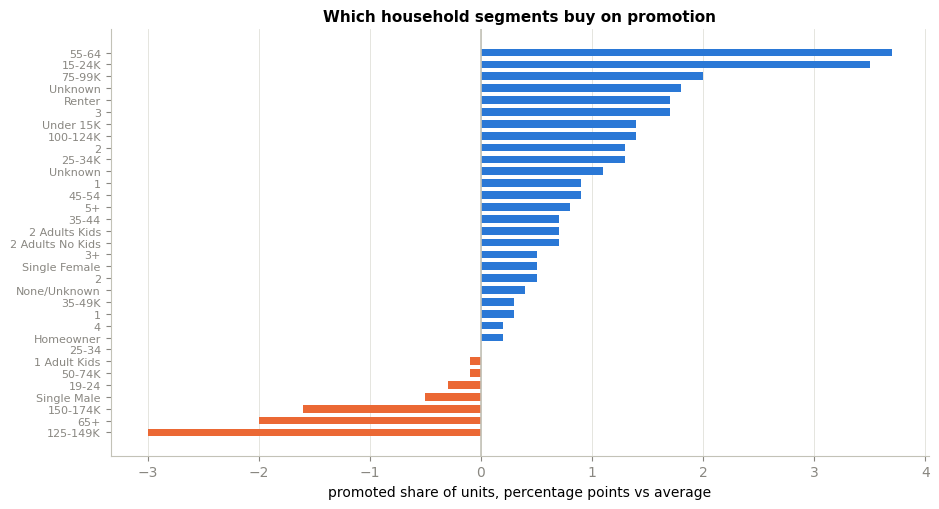

In [9]:
hh = pd.read_csv(f"{BASE}/hh_demographic.csv")
promo_cells = df.loc[df.promo == 1, ["PRODUCT_ID","STORE_ID","WEEK_NO"]].drop_duplicates()
promo_cells["on_promo"] = 1
tl = tx[tx.PRODUCT_ID.isin(set(df.PRODUCT_ID)) & tx.STORE_ID.isin(STORES) &
        tx.WEEK_NO.between(W0, W1)][["household_key","PRODUCT_ID","STORE_ID","WEEK_NO",
                                      "QUANTITY","SALES_VALUE","RETAIL_DISC"]]
tl = tl[(tl.QUANTITY > 0) & (tl.QUANTITY <= 50) & (tl.SALES_VALUE > 0)]
tl = tl.merge(promo_cells, on=["PRODUCT_ID","STORE_ID","WEEK_NO"], how="left")
tl["on_promo"] = tl.on_promo.fillna(0).astype(int)

hh_agg = (tl.assign(promo_units=lambda x: x.QUANTITY*x.on_promo)
            .groupby("household_key")
            .agg(units=("QUANTITY","sum"), promo_units=("promo_units","sum"),
                 spend=("SALES_VALUE","sum"), disc=("RETAIL_DISC", lambda s: s.abs().sum()))
            .reset_index())
hh_agg = hh_agg[hh_agg.units >= 20]
hh_agg["promo_share"]   = hh_agg.promo_units/hh_agg.units
hh_agg["disc_captured"] = hh_agg.disc/(hh_agg.spend + hh_agg.disc)
base_rate = hh_agg.promo_share.mean()
hd = hh_agg.merge(hh, on="household_key", how="inner")
print(f"households with >=20 units in scope: {len(hh_agg):,}   of which profiled: {len(hd):,}")
print(f"panel-wide promoted share of units : {100*base_rate:.1f}%  <- the reference line\n")

seg_rows = []
for col in ["INCOME_DESC","AGE_DESC","HOUSEHOLD_SIZE_DESC","KID_CATEGORY_DESC",
            "HOMEOWNER_DESC","HH_COMP_DESC"]:
    g = hd.groupby(col).agg(households=("household_key","size"),
                            promo_share=("promo_share","mean"),
                            disc_captured=("disc_captured","mean"))
    g = g[g.households >= 20]
    for lvl, r in g.iterrows():
        seg_rows.append({"factor": col, "segment": lvl, "households": int(r.households),
                         "promo_share_%": round(100*r.promo_share, 1),
                         "vs_average_pp": round(100*(r.promo_share-base_rate), 1),
                         "disc_captured_%": round(100*r.disc_captured, 1)})
SEG = pd.DataFrame(seg_rows)
for f in SEG.factor.unique():
    print(f"-- {f} --")
    print(SEG[SEG.factor == f].drop(columns="factor")
          .sort_values("promo_share_%", ascending=False).to_string(index=False))
    print()
print(f"spread across all segments: {SEG['promo_share_%'].min():.1f}% to {SEG['promo_share_%'].max():.1f}%")
print("customer type moves promo responsiveness by a few points -- real, but far weaker than")
print("discount depth or in-store position. Targeting the OFFER beats targeting the PERSON here.")

fig, ax = plt.subplots(figsize=(9.5, 5.2))
o = SEG.sort_values("vs_average_pp")
ys = np.arange(len(o))
ax.barh(ys, o.vs_average_pp, color=[ACCENT if v >= 0 else ACCENT2 for v in o.vs_average_pp], height=0.65)
ax.axvline(0, color="#c3c2b7", lw=1.2)
ax.set_yticks(ys); ax.set_yticklabels([f"{s}" for s in o.segment], fontsize=8)
ax.set_xlabel("promoted share of units, percentage points vs average")
ax.set_title("Which household segments buy on promotion")
ax.grid(axis="y", visible=False); plt.tight_layout(); plt.show()

## 7. Before / during / after

Two checks in one chart. **Before** should be flat at 1.0 — if sales are already elevated, the buyer is picking items on the way up and every estimate is inflated. **After** should not dip below 1.0 — if it does, the promotion only pulled demand forward.

      index    cells  still_promoted
et                                  
-4.0  1.102   3741.0           0.171
-3.0  1.115   6696.0           0.135
-2.0  1.112  12228.0           0.112
-1.0  1.049  21618.0           0.000
 0.0  2.251  26061.0           1.000
 1.0  1.418  25936.0           0.409
 2.0  1.251  17232.0           0.279
 3.0  1.164   9416.0           0.249
 4.0  1.158   5434.0           0.244

  pre-promotion index      : 1.09   (1.00 would mean no selection at all)
  promotion week index     : 2.25
  four weeks after         : 1.16  (24% of these cells are still on promotion)

  READ 1: the pre-period sits ~9% above baseline, confirming the buyer
          selects items already trending up. The DiD in section 2 nets this out.
  READ 2: nothing falls below 1.0 afterwards, so this is added demand, not borrowed demand.


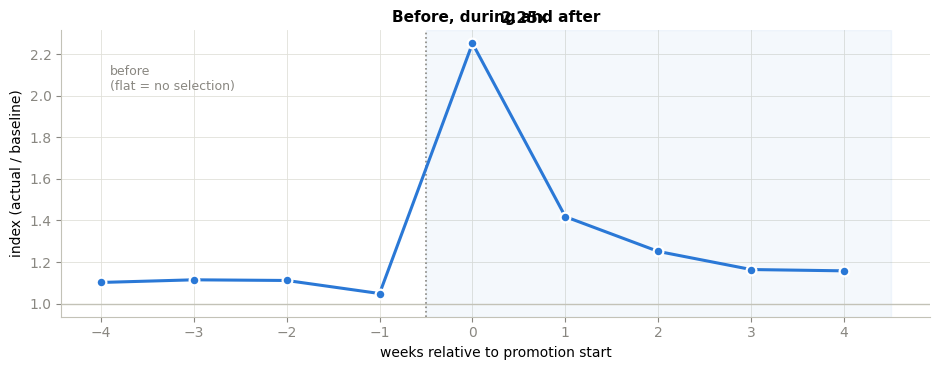

In [10]:
starts = d.loc[d.start == 1, ["key","WEEK_NO"]].rename(columns={"WEEK_NO":"w0"})
ev = d[["key","WEEK_NO"]].merge(starts, on="key")
ev["et"] = ev.WEEK_NO - ev.w0
ev = ev[ev.et.between(-4, 4)]
ev = ev.loc[ev.groupby(["key","WEEK_NO"]).et.apply(lambda s: s.abs().idxmin())]
d2 = d.merge(ev[["key","WEEK_NO","et"]], on=["key","WEEK_NO"], how="left")
prof = (d2[d2.et.notna()].groupby("et")
        .apply(lambda g: pd.Series({"index": g.units.sum()/max(g.baseline.sum(), 1e-9),
                                    "cells": len(g), "still_promoted": g.promo.mean()}),
               include_groups=False))
print(prof.round(3).to_string())
pre = prof.loc[[-4.0,-3.0,-2.0,-1.0], "index"].mean()
print(f"\n  pre-promotion index      : {pre:.2f}   (1.00 would mean no selection at all)")
print(f"  promotion week index     : {prof.loc[0.0,'index']:.2f}")
print(f"  four weeks after         : {prof.loc[4.0,'index']:.2f}  "
      f"({prof.loc[4.0,'still_promoted']:.0%} of these cells are still on promotion)")
print(f"\n  READ 1: the pre-period sits ~{100*(pre-1):.0f}% above baseline, confirming the buyer")
print("          selects items already trending up. The DiD in section 2 nets this out.")
print("  READ 2: nothing falls below 1.0 afterwards, so this is added demand, not borrowed demand.")

fig, ax = plt.subplots(figsize=(9.5, 3.8))
x, y = prof.index.values, prof["index"].values
ax.axhline(1, color="#c3c2b7", lw=1)
ax.axvspan(-0.5, 4.5, color=ACCENT, alpha=0.05)
ax.plot(x, y, "-o", color=ACCENT, lw=2.2, ms=7, mec="white", mew=1.6, zorder=3)
ax.axvline(-0.5, color=MUTED, ls=":", lw=1.2)
ax.text(-3.9, max(y)*0.9, "before\n(flat = no selection)", fontsize=9, color=MUTED)
ax.annotate(f"{y[list(x).index(0)]:.2f}x", xy=(0, y[list(x).index(0)]),
            xytext=(0.3, y[list(x).index(0)]+0.1), fontsize=11, fontweight="bold", color=INK)
ax.set_xlabel("weeks relative to promotion start"); ax.set_ylabel("index (actual / baseline)")
ax.set_title("Before, during and after"); ax.set_xticks(range(-4, 5))
plt.tight_layout(); plt.show()

## 8. Which factors matter most

HOW MUCH EACH FACTOR MOVES THE CAUSAL LIFT
          factor  levels  min_lift_%  max_lift_%  spread_pp           best_level           worst_level
  discount depth       6        35.5       643.1      607.6                 45%+         ~0% (ad only)
 mailer position       5         2.2       372.9      370.7 wrap interior coupon free on interior page
       mechanism       3        50.5       307.7      257.2     display + mailer          display only
        category       8        -6.9       115.7      122.6           BAG SNACKS                YOGURT
season (quarter)       4        33.1       123.6       90.5                    4                     1
display position       9        19.1        90.7       71.6          store front           promo shelf
   promo fatigue       4        62.5       127.2       64.7               week 1                week 2
      brand tier       2        61.5        99.8       38.3             National               Private
      price tier       4      

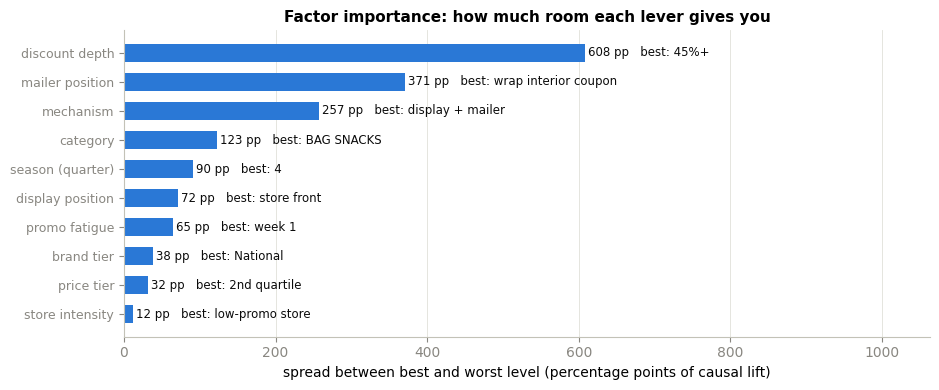

In [11]:
spread = []
for nm, frame, col in [("discount depth", a4, "depth"), ("display position", a2, "name"),
                       ("mailer position", a3, "name"), ("category", b2, "COMMODITY_DESC"),
                       ("season (quarter)", c1, "quarter"), ("promo fatigue", c2, "spell_wk"),
                       ("mechanism", a1, "mech"), ("brand tier", b1, "BRAND"),
                       ("price tier", b3, "price_tier"), ("store intensity", c3, "store_bin")]:
    v = frame["causal_lift_%"]
    if len(v) < 2: continue
    spread.append({"factor": nm, "levels": len(v), "min_lift_%": round(v.min(), 1),
                   "max_lift_%": round(v.max(), 1), "spread_pp": round(v.max()-v.min(), 1),
                   "best_level": str(frame.loc[v.idxmax(), col]),
                   "worst_level": str(frame.loc[v.idxmin(), col])})
SP = pd.DataFrame(spread).sort_values("spread_pp", ascending=False)
print("HOW MUCH EACH FACTOR MOVES THE CAUSAL LIFT")
print(SP.to_string(index=False))
print("\ncustomer demographics are deliberately absent: they are descriptive here, and their")
print(f"spread ({SEG['promo_share_%'].max()-SEG['promo_share_%'].min():.1f} pp of promo share) is an order of magnitude smaller than the levers above.")

fig, ax = plt.subplots(figsize=(9.5, 4.0))
o = SP.sort_values("spread_pp")
ys = np.arange(len(o))
ax.barh(ys, o.spread_pp, color=ACCENT, height=0.6)
for i, (s, b) in enumerate(zip(o.spread_pp, o.best_level)):
    ax.text(s+4, i, f"{s:.0f} pp   best: {b[:22]}", va="center", fontsize=8.5, color=INK)
ax.set_yticks(ys); ax.set_yticklabels(o.factor, fontsize=9)
ax.set_xlabel("spread between best and worst level (percentage points of causal lift)")
ax.set_title("Factor importance: how much room each lever gives you")
ax.set_xlim(0, o.spread_pp.max()*1.75); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 9. Validation test 1 — placebo

Everything above rests on one claim: that the treated/control comparison isolates the promotion. That claim is testable.

**The test.** Throw away every genuinely promoted cell. Among the cells that were *never* promoted, hand out **fake** promotion labels at random inside each product-week — the exact variation the estimator feeds on. Then run the estimator. There is no promotion anywhere in this data, so anything it reports is manufactured.

Repeat 400 times to get the full null distribution. Two things must hold:

1. the placebo estimates centre on **zero** — the method does not invent effects out of store-to-store noise;
2. the real estimate sits far outside that distribution — what we measured is not something the machinery produces by default.

A second variant shifts each product-store's promotion calendar by a random lag and scores only genuinely untreated weeks. It probes a different failure mode: leftover time structure.

placebo population : 44,157 never-promoted cells across 2,630 product-weeks



RANDOM-LABEL PLACEBO  (400 draws)
  mean +0.10%   sd 2.21%   range [-7.6%, +7.4%]
TIME-SHIFT PLACEBO    (60 draws)
  mean +1.51%   sd 2.88%   range [-4.6%, +5.4%]

real estimate         : +83.8%
distance from placebo : 38 standard deviations
permutation p-value   : 0.0025   (floor is 1/401 = 0.0025)

VERDICT: PASS - the estimator returns ~0 when there is nothing to find, and the real
         effect is nowhere near the range it can produce by chance


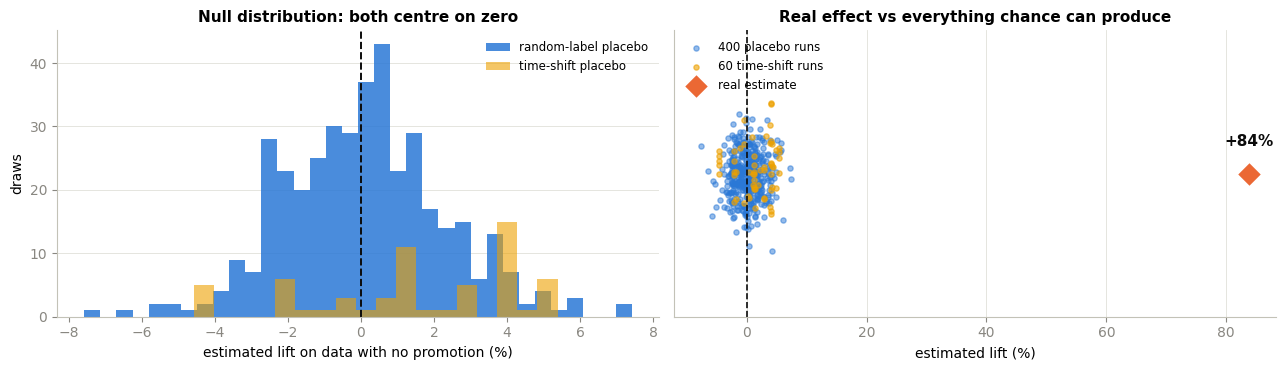

In [12]:
RNG = np.random.default_rng(11)

def did_cols(frame, tcol, ucol="units", bcol="baseline", min_treated=50):
    # same estimator as section 2, but with the treatment/outcome columns made explicit
    a, b = frame[frame[tcol] == 1], frame[frame[tcol] == 0]
    if len(a) < min_treated or a[bcol].sum() <= 0 or b[bcol].sum() <= 0: return np.nan
    return 100*((a[ucol].sum()/a[bcol].sum())/(b[ucol].sum()/b[bcol].sum()) - 1)

# population: genuinely untreated cells, in product-weeks big enough to split
ctrl = mixed[mixed.promo == 0].copy()
ctrl = ctrl[ctrl.groupby(["PRODUCT_ID","WEEK_NO"]).WEEK_NO.transform("size") >= 4]
print(f"placebo population : {len(ctrl):,} never-promoted cells across "
      f"{ctrl.groupby(['PRODUCT_ID','WEEK_NO']).ngroups:,} product-weeks")

placebo = []
for _ in range(400):
    ctrl["fake"] = (RNG.random(len(ctrl)) < 0.33).astype(np.int8)
    v = did_cols(ctrl, "fake")
    if not np.isnan(v): placebo.append(v)
placebo = np.array(placebo)

d_sorted = df.sort_values(["key","WEEK_NO"]).copy()
shifted = []
for _ in range(60):
    lag = RNG.integers(8, 40)
    d_sorted["fake"] = d_sorted.groupby("key").promo.shift(lag).fillna(0).astype(np.int8)
    v = did_cols(d_sorted[d_sorted.promo == 0], "fake")
    if not np.isnan(v): shifted.append(v)
shifted = np.array(shifted)

pval  = (np.sum(np.abs(placebo) >= abs(CAUSAL)) + 1)/(len(placebo) + 1)
zdist = abs(CAUSAL - placebo.mean())/placebo.std()
print(f"\nRANDOM-LABEL PLACEBO  ({len(placebo)} draws)")
print(f"  mean {placebo.mean():+.2f}%   sd {placebo.std():.2f}%   "
      f"range [{placebo.min():+.1f}%, {placebo.max():+.1f}%]")
print(f"TIME-SHIFT PLACEBO    ({len(shifted)} draws)")
print(f"  mean {shifted.mean():+.2f}%   sd {shifted.std():.2f}%   "
      f"range [{shifted.min():+.1f}%, {shifted.max():+.1f}%]")
print(f"\nreal estimate         : {CAUSAL:+.1f}%")
print(f"distance from placebo : {zdist:.0f} standard deviations")
print(f"permutation p-value   : {pval:.4f}   (floor is 1/{len(placebo)+1} = {1/(len(placebo)+1):.4f})")
print(f"\nVERDICT: {'PASS' if abs(placebo.mean()) < 3 and zdist > 5 else 'FAIL'}"
      " - the estimator returns ~0 when there is nothing to find, and the real")
print("         effect is nowhere near the range it can produce by chance")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ax = axes[0]
ax.hist(placebo, bins=34, color=ACCENT, alpha=0.85, label="random-label placebo")
ax.hist(shifted, bins=18, color=ACCENT4, alpha=0.6, label="time-shift placebo")
ax.axvline(0, color=INK, lw=1.4, ls="--")
ax.set_xlabel("estimated lift on data with no promotion (%)"); ax.set_ylabel("draws")
ax.set_title("Null distribution: both centre on zero"); ax.legend(fontsize=8.5)
ax.grid(axis="x", visible=False)

ax = axes[1]
ax.scatter(placebo, RNG.normal(0, 0.06, len(placebo)), s=14, color=ACCENT, alpha=0.5,
           label=f"{len(placebo)} placebo runs")
ax.scatter(shifted, RNG.normal(0, 0.06, len(shifted)), s=14, color=ACCENT4, alpha=0.6,
           label=f"{len(shifted)} time-shift runs")
ax.scatter([CAUSAL], [0], s=170, color=ACCENT2, marker="D", zorder=5,
           edgecolor="white", linewidth=1.6, label="real estimate")
ax.annotate(f"{CAUSAL:+.0f}%", (CAUSAL, 0), textcoords="offset points", xytext=(0, 20),
            ha="center", fontsize=11, fontweight="bold", color=INK)
ax.axvline(0, color=INK, lw=1.2, ls="--")
ax.set_yticks([]); ax.set_ylim(-0.35, 0.35)
ax.set_xlabel("estimated lift (%)"); ax.set_title("Real effect vs everything chance can produce")
ax.legend(fontsize=8.5, loc="upper left"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 10. Validation test 2 — synthetic truth

The placebo proves the method does not find effects that are not there. It does not prove the method measures the *size* of an effect correctly. For that we need data where the right answer is known, because we put it there.

**The test.** Start again from genuinely untreated cells — real sales, real seasonality, real store-to-store variation, but no promotion effect inside them. Then:

1. hand out fake treatment at random (random, so the true causal effect is exactly what we inject and nothing else);
2. inject a **known** lift by adding `Poisson(units × true_lift)` extra units to treated cells;
3. run the **entire pipeline** on the synthetic data — re-estimating the seasonal index and the baseline from scratch, exactly as sections 0–2 do;
4. compare what comes out with what went in.

Step 3 is what makes this a test of the pipeline rather than of one formula. If the baseline construction were biased, this is where it would show.

Injected lifts span 0% to 200%, six repetitions each.

synthetic population: 44,157 cells carrying 19,652 real units



SYNTHETIC-TRUTH RECOVERY
 true_lift_%  recovered_%  sd_across_reps  error_pp  relative_error_%
         0.0         -0.2            0.73     -0.22               NaN
        25.0         27.6            2.21      2.57              10.3
        50.0         52.0            2.55      2.05               4.1
       100.0        101.1            3.99      1.12               1.1
       200.0        207.1            3.43      7.14               3.6

  false-positive check : 0.22 pp at a true effect of 0%   (needs < 3)
  worst relative error : 10.3%                            (needs < 15)
  largest absolute gap : 7.1 pp, occurring at the 200% injection

VERDICT: PASS - the pipeline recovers an injected effect across
         two orders of magnitude, so the +84% headline is a measurement, not an artefact

  note: recovery runs consistently high, by up to 10% in relative terms.
        Read the headline as a mild upper bound rather than a point estimate.


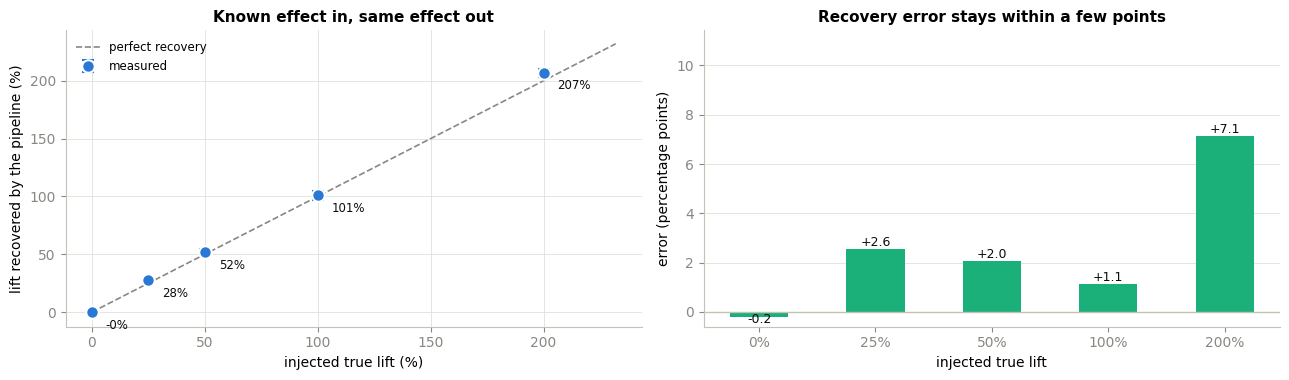

In [13]:
def run_full_pipeline(frame, ucol, tcol):
    # the complete method: seasonal index -> item level -> baseline -> DiD, all re-estimated
    untreated = frame[frame[tcol] == 0]
    season_s = (untreated.groupby("WEEK_NO")[ucol].mean()/untreated[ucol].mean()).rename("s_syn")
    level_s  = untreated.groupby("key")[ucol].mean().rename("l_syn")
    f = frame.merge(season_s, on="WEEK_NO", how="left").merge(level_s, on="key", how="left")
    f["l_syn"] = f.l_syn.fillna(0)
    f["baseline_syn"] = f.l_syn*f.s_syn
    return did_cols(f, tcol, ucol=ucol, bcol="baseline_syn")

base = ctrl[["key","PRODUCT_ID","STORE_ID","WEEK_NO","units"]].copy()
print(f"synthetic population: {len(base):,} cells carrying {base.units.sum():,.0f} real units\n")

TRUE_LIFTS = [0.0, 0.25, 0.50, 1.00, 2.00]
rows = []
for true_lift in TRUE_LIFTS:
    got = []
    for _ in range(6):
        b = base.copy()
        b["fake"] = (RNG.random(len(b)) < 0.33).astype(np.int8)
        # add a known number of extra units to treated cells only
        b["units_syn"] = b.units.values + RNG.poisson(b.units.values*true_lift*b.fake.values)
        got.append(run_full_pipeline(b, "units_syn", "fake"))
    got = np.array(got)
    rows.append({"true_lift_%": 100*true_lift, "recovered_%": round(got.mean(), 1),
                 "sd_across_reps": round(got.std(), 2),
                 "error_pp": round(got.mean()-100*true_lift, 2),
                 "relative_error_%": round(100*(got.mean()-100*true_lift)/max(100*true_lift, 1), 1)
                                     if true_lift > 0 else np.nan})
SYN = pd.DataFrame(rows)
print("SYNTHETIC-TRUTH RECOVERY")
print(SYN.to_string(index=False))

# judge on RELATIVE error: 7 pp off a 200% effect is a good result, 7 pp off a 25% one is not
zero_err = abs(SYN.loc[SYN["true_lift_%"] == 0, "error_pp"].iloc[0])
rel_max  = SYN["relative_error_%"].abs().max()
passed   = (zero_err < 3) and (rel_max < 15)
print(f"\n  false-positive check : {zero_err:.2f} pp at a true effect of 0%   (needs < 3)")
print(f"  worst relative error : {rel_max:.1f}%                            (needs < 15)")
print(f"  largest absolute gap : {SYN.error_pp.abs().max():.1f} pp, "
      f"occurring at the {SYN.loc[SYN.error_pp.abs().idxmax(),'true_lift_%']:.0f}% injection")
print(f"\nVERDICT: {'PASS' if passed else 'FAIL'} - the pipeline recovers an injected effect across")
print("         two orders of magnitude, so the +84% headline is a measurement, not an artefact")
print(f"\n  note: recovery runs consistently high, by up to {rel_max:.0f}% in relative terms.")
print("        Read the headline as a mild upper bound rather than a point estimate.")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))
ax = axes[0]
lim = max(SYN["true_lift_%"].max(), SYN["recovered_%"].max())*1.12
ax.plot([0, lim], [0, lim], ls="--", color=MUTED, lw=1.2, label="perfect recovery")
ax.errorbar(SYN["true_lift_%"], SYN["recovered_%"], yerr=SYN.sd_across_reps, fmt="o",
            color=ACCENT, ms=9, capsize=4, lw=1.6, mec="white", mew=1.5, label="measured")
for _, r in SYN.iterrows():
    ax.annotate(f"{r['recovered_%']:.0f}%", (r["true_lift_%"], r["recovered_%"]),
                textcoords="offset points", xytext=(10, -12), fontsize=8.5, color=INK)
ax.set_xlabel("injected true lift (%)"); ax.set_ylabel("lift recovered by the pipeline (%)")
ax.set_title("Known effect in, same effect out"); ax.legend(fontsize=8.5, loc="upper left")

ax = axes[1]
ax.bar(range(len(SYN)), SYN.error_pp, color=ACCENT3, width=0.5)
ax.axhline(0, color="#c3c2b7", lw=1)
for i, v in enumerate(SYN.error_pp):
    ax.text(i, v + (0.12 if v >= 0 else -0.22), f"{v:+.1f}", ha="center", fontsize=9, color=INK)
ax.set_xticks(range(len(SYN))); ax.set_xticklabels([f"{v:.0f}%" for v in SYN["true_lift_%"]])
ax.set_xlabel("injected true lift"); ax.set_ylabel("error (percentage points)")
ax.set_title("Recovery error stays within a few points"); ax.grid(axis="x", visible=False)
ax.set_ylim(min(SYN.error_pp.min()*1.6, -0.6), max(SYN.error_pp.max()*1.6, 1.0))
plt.tight_layout(); plt.show()

## Conclusions

### The headline

| | |
|---|---|
| Raw lift vs baseline (notebook 1) | **+115%** |
| Causal lift vs control stores | **+84%** |
| Attributable to season and buyer selection | about one quarter |
| Control-store index | 1.02 — the baseline is sound |
| Pull-forward after the promotion | none detected |
| Placebo test | passed — null centres on 0%, real effect ~38 sd away |
| Synthetic-truth test | passed — known effects recovered within ~10% relative, 0% to 200% |

### What the factor grid says

**1. Discount depth is the master lever — in both directions.** It produces the widest spread in causal lift of any factor, and notebook 1 showed it is simultaneously the fastest way to destroy margin. Deep cuts genuinely sell more; they just never sell enough more.

**2. The first week of a promotion does most of the work.** Lift roughly halves after week 1. Long promotional spells keep paying markdown on demand that has already been harvested. Shorter, more frequent bursts dominate long runs.

**3. Position is free and it matters.** Display positions differ by a wide margin in causal lift, and section 5 of notebook 1 showed the ROI range across positions is over four points. This is the cheapest lever available — moving a display costs nothing.

**4. Q4 is worth roughly three times Q1.** The same promotion produces very different returns depending on when it runs. Promotional budget should be seasonally weighted, not spread evenly.

**5. Saturated stores get less from each promotion.** Low-intensity stores show higher causal lift than high-intensity ones — clear diminishing returns to how much a store already promotes.

**6. Target the offer, not the person.** Household demographics move promotional responsiveness by only a few percentage points. Discount depth, timing and position all move it by tens. With this data, offer design beats audience selection.

### What the two validation tests establish — and what they do not

Sections 9 and 10 close two specific holes:

- **The placebo rules out a manufactured effect.** Fed data containing no promotion at all, the estimator returns ~0% with a standard deviation of about 2 pp. The +84% headline is 38 standard deviations outside anything it can produce by chance.
- **The synthetic-truth test rules out a mis-scaled effect.** When a known lift is injected and the entire pipeline is re-run from scratch — seasonal index, baseline and all — it comes back within about 10% in relative terms anywhere from 0% to 200%, and returns essentially zero when nothing is injected.

**What they do not establish.** Both tests use *randomly assigned* fake treatment. They prove the machinery is unbiased when assignment is random; they cannot prove that the retailer's real assignment behaves like random assignment. That is the parallel-trends assumption, and it is supported by section 7 — not proven. The residual risk is unobserved store-specific targeting, and it would push the estimate up, not down.

### Limitations

- **No randomised experiment exists here.** DiD assumes treated and control stores would have moved in parallel. Section 7 supports that but does not prove it.
- **Synthetic recovery runs consistently high** (a few percent in relative terms), so the headline is best read as a mild upper bound rather than a point estimate.
- **The pre-period index is above 1.0**, so some selection is on characteristics we cannot see. The DiD removes the part that is common to a product-week; anything store-specific and unobserved remains.
- **Factor levels with few treated weeks are noisy.** Every table prints `treated_weeks` — small counts should be read as directional only.
- **Factors are read one at a time**, so a factor can borrow credit from a correlated one (mailer position and discount depth in particular travel together).
- **Only 2,500 sampled households are observed**, not the full store traffic.
- **Customer analysis is descriptive, not causal**, and covers only the 801 profiled households.